In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional

from utils import REGIONS, DATA_DIR, METHODS


In [ ]:
# User defined variables
SCENARIO = "et-vlow-mgas" # do not change
CMAP_OVERRIDE = None # https://matplotlib.org/stable/users/explain/colors/colormaps.html
SENSITIVITIES = [5,10,20,100]

In [26]:
# Path handling (DO NOT CHANGE)
FIGURES_BASE = Path("..","figures","sa")

In [94]:
# Formatting (DO NOT CHANGE)
OBJ_COST_SCALER = 1e9
PEAKINESS_SCALER = 1e3
PEAK_NET_LOAD_SCALER = 1e3
RAMPING_SCALER = 1e3
CAPACITY_SCALER = 1e3
EMISSIONS_SCALER = 1e6
GENERATION_SCALER = 1e3

METHOD_NICE_NAMES = {
    "static": "Carrier-Average",
    "dynamic": "Carrier-Specific",
}

REGION_NICE_NAMES = {
    "caiso": "California",
    "new_england": "New England",
    "caiso_cc": "Capacity Constrained\nCalifornia",
}


In [28]:
def get_template_dataframe() -> pd.DataFrame:
    regions = REGIONS.copy()
    adoptions = SENSITIVITIES.copy()
    adoptions.insert(0, 0)
    return pd.DataFrame([],
        index=regions,
        columns=adoptions
    )
get_template_dataframe()

,0,5,10,20,100
caiso,NaN,NaN,NaN,NaN,NaN
new_england,NaN,NaN,NaN,NaN,NaN
caiso_cc,NaN,NaN,NaN,NaN,NaN


In [108]:
def get_sensitivity_prefix(region: str) -> str:
    if region == "caiso":
        return "c"
    elif region == "new_england":
        return "ne"
    elif region == "caiso_cc":
        return "cc"
    else:
        raise ValueError(f"Invalid region: {region}")

def get_sa_datapoint(
    region: str,
    result: str,
    method: Optional[str] = None,
    sensitivity: Optional[int] = None,
) -> pd.DataFrame:
    """Get the datapoint for a given NG price, sector, and DR price"""
    assert region in REGIONS, f"Invalid region: {region}. Expected one of {REGIONS}"
    
    if method and sensitivity:
        prefix = get_sensitivity_prefix(region)
        p = Path(
            DATA_DIR,
            region,
            "sensitivity_analysis",
            "processed",
            method,
            f"{prefix}{sensitivity}",
            "datapoint",
            f"{result}.csv",
        )
    else:
        p = Path(
            DATA_DIR,
            region,
            "sensitivity_analysis",
            "processed",
            "no_dr",
            "datapoint",
            f"{result}.csv",
        )

    assert p.exists(), (
        f"Data point not found for:{p}"
    )

    return pd.read_csv(p, index_col=0)

In [88]:
def get_heatmap_data(result: str, metric: str, as_percentage: bool = False) -> dict[str, pd.DataFrame]:
    data = {}
    for method in METHODS:
        hm = get_template_dataframe()
        for region in hm.index:
            for adoption in hm.columns:
                sensitivity = adoption if adoption != 0 else None
                df = get_sa_datapoint(
                    region=region,
                    result=result,
                    method=method,
                    sensitivity=sensitivity
                )
                datapoint = float(df.at[metric, "value"])
                hm.at[region, adoption] = datapoint
        if as_percentage:
            for adoption in hm.columns:
                if adoption == 0:
                    continue
                hm[adoption] = (hm[adoption] - hm[0]).div(hm[0]).mul(100).round(2)
        data[method] = hm.astype(float)
    return data

In [112]:
def plot_sensitivities(result: str, metric: str, scaler: Optional[float] = None, ylabel: Optional[str] = None) -> tuple[plt.figure, plt.axes]:
    data = get_heatmap_data(result, metric, as_percentage=False)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    for i, (method, df) in enumerate(data.items()):
        scaled = df.div(scaler)
        scaled = scaled.rename(index=REGION_NICE_NAMES)
        scaled.T.plot(ax=axs[i], legend=False, marker="o", markersize=5)
        axs[i].set_title(METHOD_NICE_NAMES[method], fontsize=14)
        if ylabel:
            axs[i].set_ylabel(ylabel, fontsize=14)
            axs[i].tick_params(labelleft=True, labelsize=14)
        
    axs[0].set_xlabel("Allowable load contribution (%)", fontsize=14)
    axs[1].set_xlabel("Allowable load contribution (%)", fontsize=14)
        
    handles, labels = axs[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.90, 0.75),
        frameon=False,
        fontsize=14
    )

    return fig, axs

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Carrier-Average'}, xlabel='Allowable load contribution (%)', ylabel='Cost ($B)'>,
        <Axes: title={'center': 'Carrier-Specific'}, xlabel='Allowable load contribution (%)', ylabel='Cost ($B)'>],
       dtype=object))

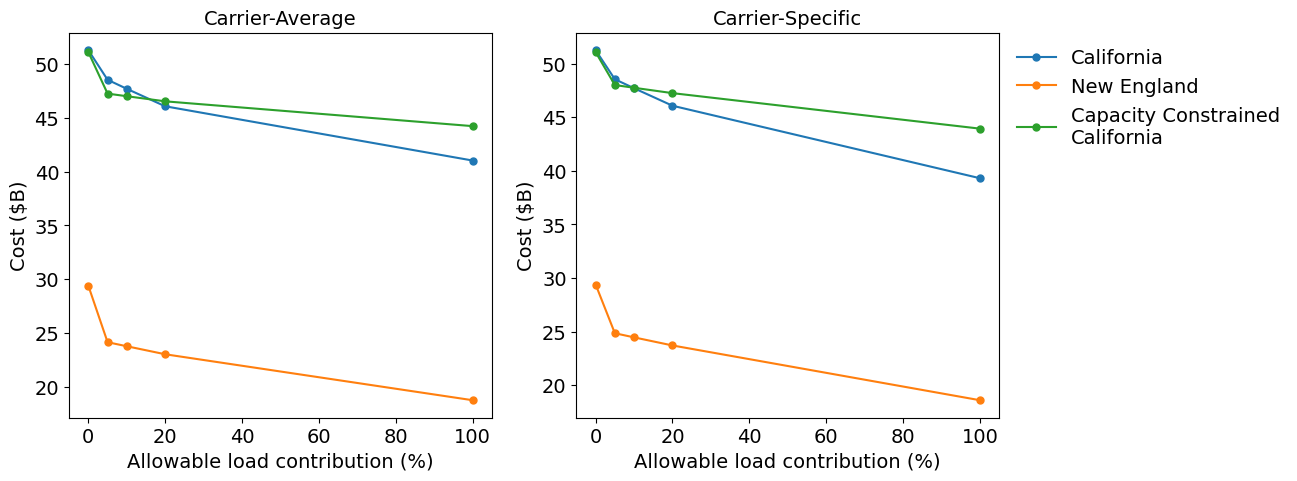

In [113]:
plot_sensitivities("cost", "objective_adj", scaler = OBJ_COST_SCALER, ylabel="Cost ($B)")

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Carrier-Average'}, xlabel='Allowable load shift (%)', ylabel='Emissions (MMT CO2e)'>,
        <Axes: title={'center': 'Carrier-Specific'}, xlabel='Allowable load shift (%)', ylabel='Emissions (MMT CO2e)'>],
       dtype=object))

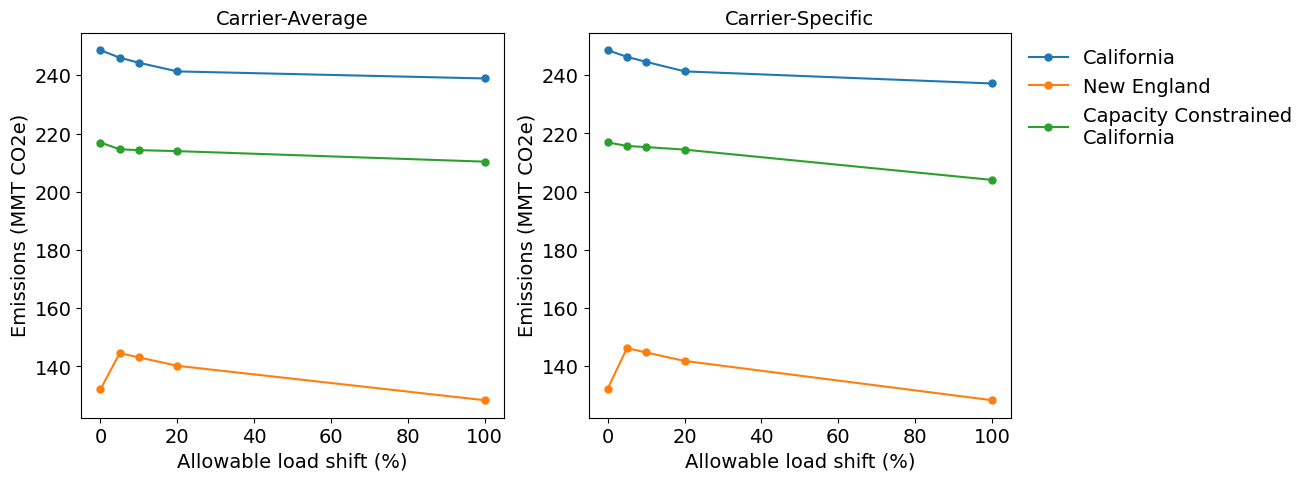

In [111]:
plot_sensitivities("emissions", "Emissions CO2 T", scaler = EMISSIONS_SCALER, ylabel="Emissions (MMT CO2e)")